In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../Datasets/weight-height.csv')

In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


C:\Users\anush\AppData\Local\Temp\ipykernel_24184\1164144932.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])
C:\Users\anush\AppData\Local\Temp\ipykernel_24184\1164144932.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


Text(0.5, 1.0, 'Weight')

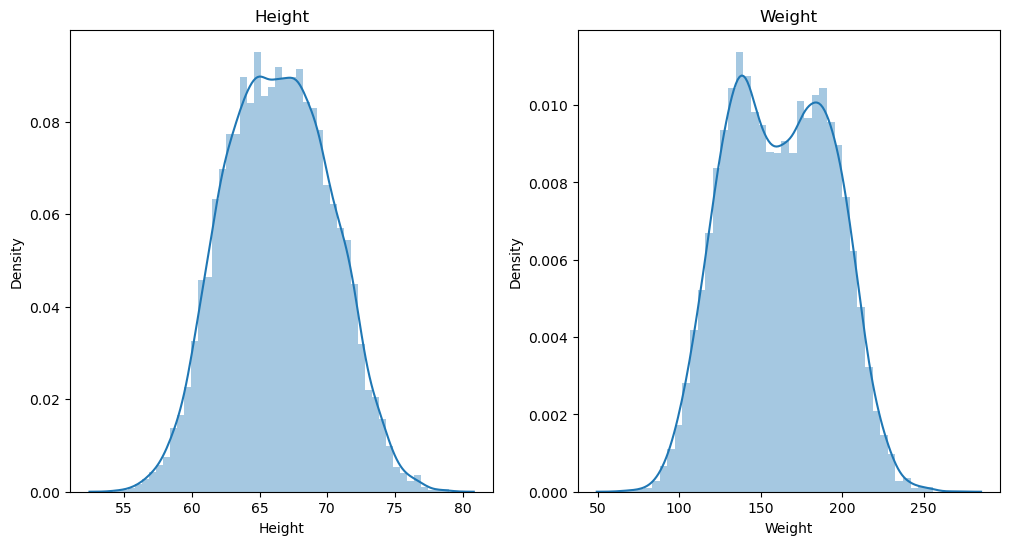

In [5]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.distplot(df['Height'])
plt.title("Height")
plt.subplot(122)
sns.distplot(df['Weight'])
plt.title("Weight")

Text(0.5, 1.0, 'Weight')

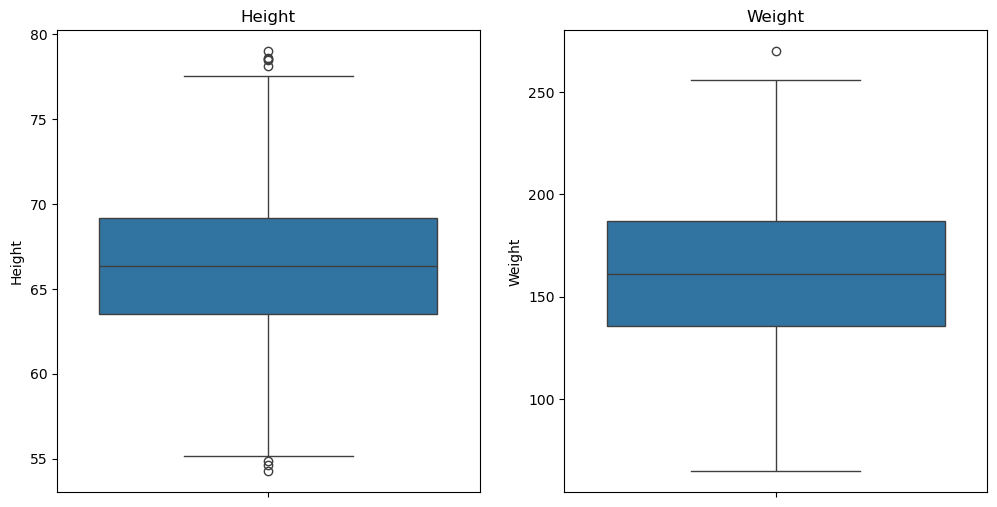

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.boxplot(df['Height'])
plt.title("Height")
plt.subplot(122)
sns.boxplot(df['Weight'])
plt.title("Weight")

In [7]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [8]:
upper_limit=df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [9]:
lower_limit=df['Height'].quantile(0.01)
lower_limit

58.13441158671655

In [11]:
df[(df['Height']>=upper_limit)|(df['Height']<=lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


#### Trimming

In [14]:
new_df=df[(df['Height']<=upper_limit)&(df['Height']>=lower_limit)]
new_df.shape

(9800, 3)

Text(0.5, 1.0, 'After Height')

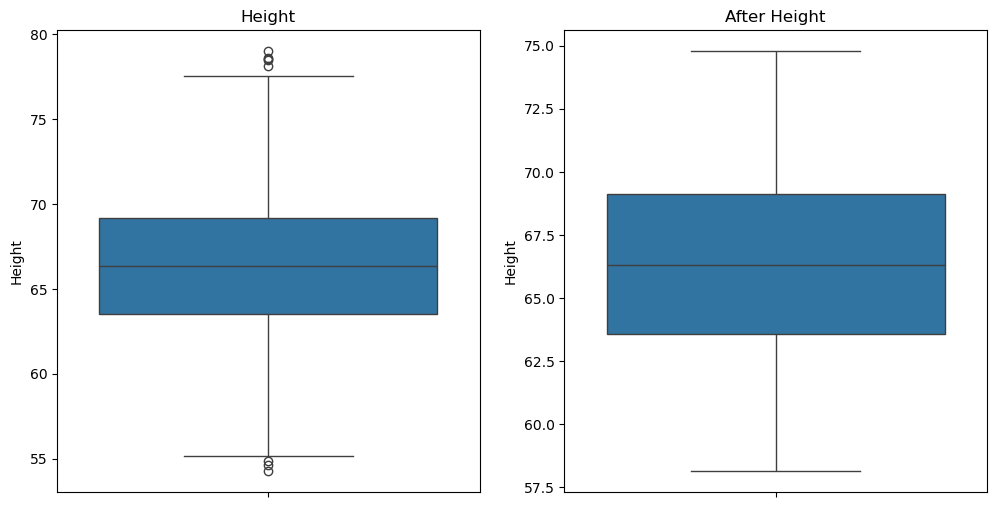

In [17]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.boxplot(df['Height'])
plt.title("Height")
plt.subplot(122)
sns.boxplot(new_df['Height'])
plt.title("After Height")

C:\Users\anush\AppData\Local\Temp\ipykernel_24184\2568539775.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])
C:\Users\anush\AppData\Local\Temp\ipykernel_24184\2568539775.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


Text(0.5, 1.0, 'AF=fter Height')

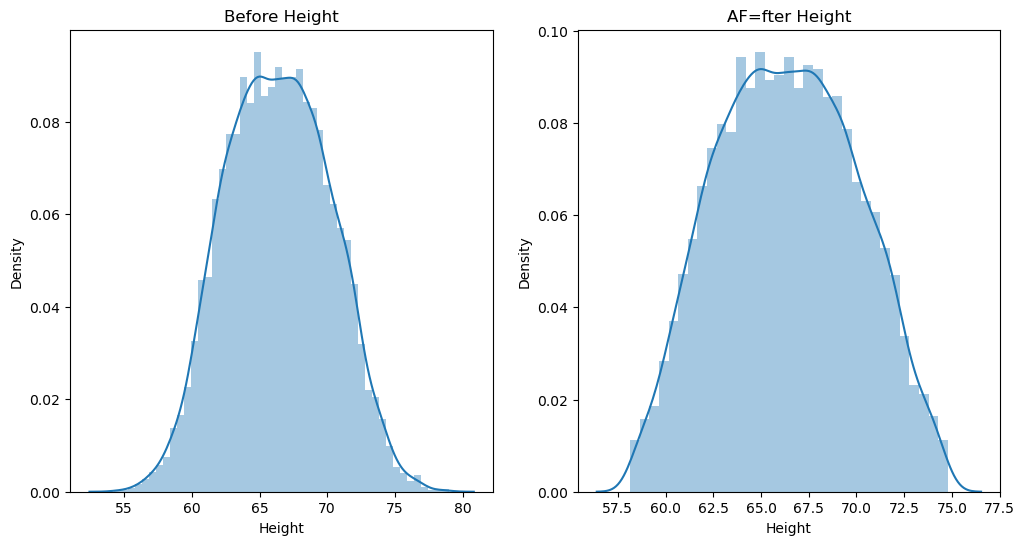

In [19]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.distplot(df['Height'])
plt.title("Before Height")
plt.subplot(122)
sns.distplot(new_df['Height'])
plt.title("AF=fter Height")

#### Capping/Winsorization

In [20]:
df['new_Height']=np.where(
    df['Height']>upper_limit,
    upper_limit,
    np.where(
        df['Height']<lower_limit,
        lower_limit,
        df['Height']
    )
)

C:\Users\anush\AppData\Local\Temp\ipykernel_24184\404315098.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])
C:\Users\anush\AppData\Local\Temp\ipykernel_24184\404315098.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['new_Height'])


Text(0.5, 1.0, 'AF=fter Height')

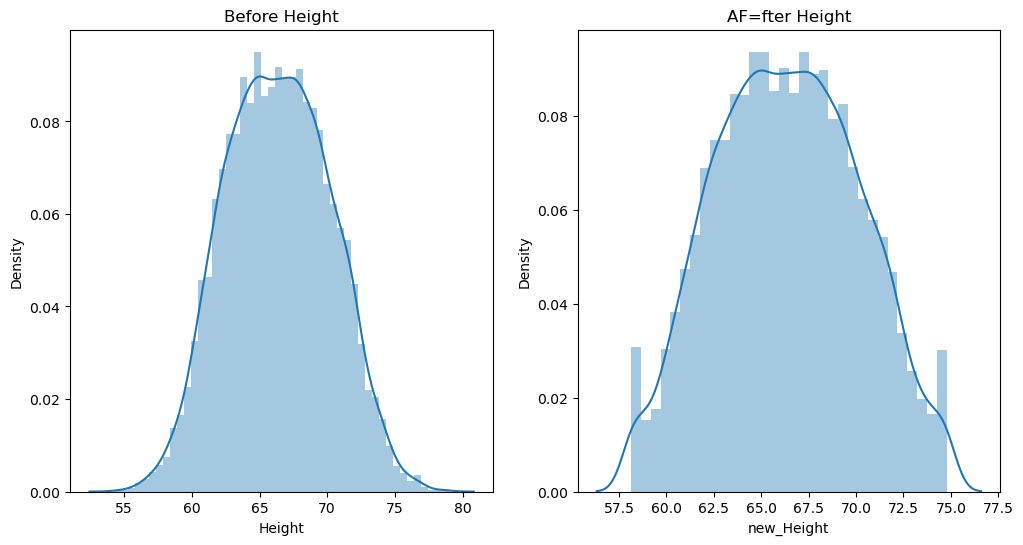

In [21]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.distplot(df['Height'])
plt.title("Before Height")
plt.subplot(122)
sns.distplot(df['new_Height'])
plt.title("AF=fter Height")

Text(0.5, 1.0, 'AF=fter Height')

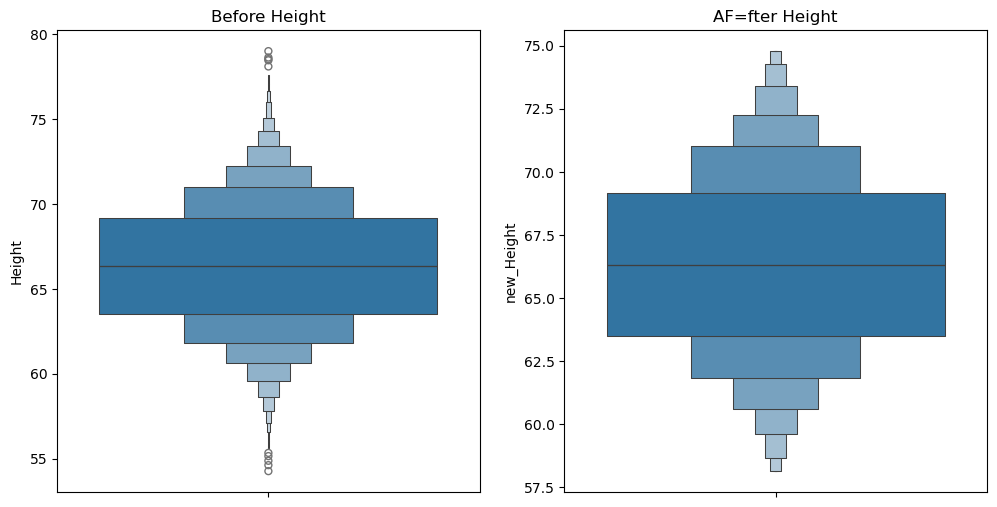

In [22]:
plt.figure(figsize=(12,6))
plt.subplot(121)
sns.boxenplot(df['Height'])
plt.title("Before Height")
plt.subplot(122)
sns.boxenplot(df['new_Height'])
plt.title("AF=fter Height")